In [ ]:
words = open('names.txt', 'r').read().splitlines()

In [ ]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [ ]:
min(len(word) for word in words)

2

In [ ]:
max(len(word) for word in words)

15

# Simple Bigram Frequency
Predict the next character in a sequence, given just the previous character.

Simplest solution: To predict, count to see which pairs occur most in the training set.
Here, we use a dictionary.

In [ ]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):  # Pairs word with word shifted left by one
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1        

In [ ]:
sorted(b.items(), key = lambda kv: kv[1], reverse=True)  # sort by count = value in (key, value)

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [ ]:
import torch

In [ ]:
a = torch.zeros((3, 5), dtype=torch.int32)
a[1, 3] = 1
a[0, 0] = 5
a

tensor([[5, 0, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

## Now we define the bigram model using a PyTorch tensor

In [ ]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s,i in stoi.items()}  # for inverse mapping

In [ ]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):  # Pairs word with word shifted left by one
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

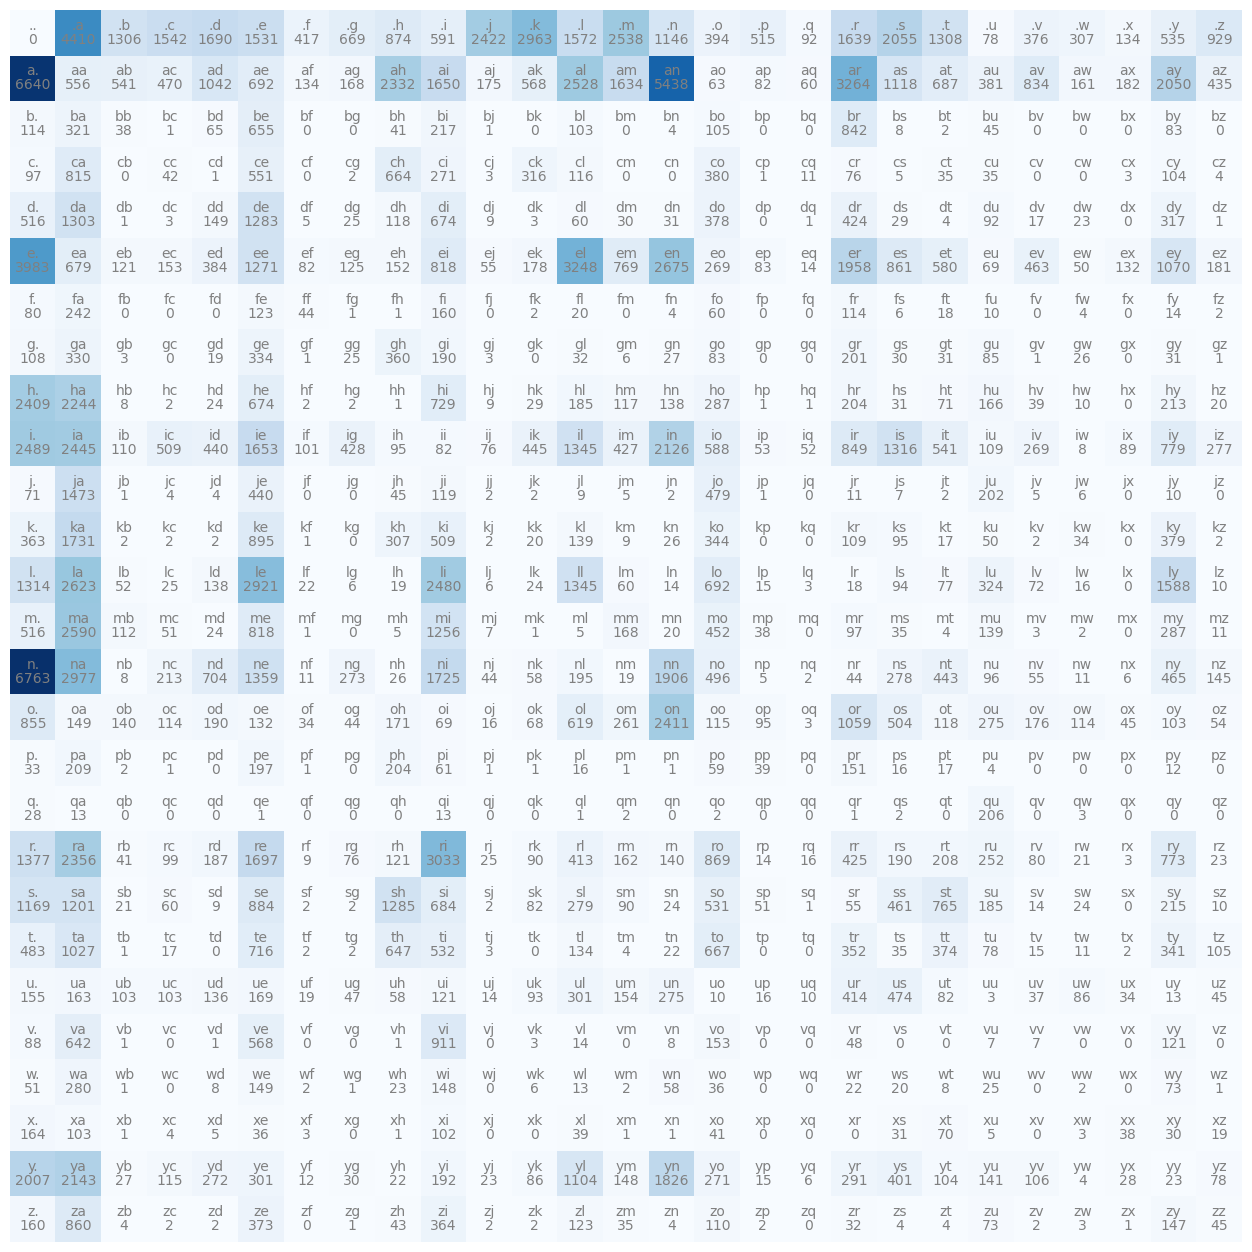

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')

plt.axis('off')

In [ ]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [ ]:
p = N[0].float()  # First row represents count beginning with char 0
p = p / p.sum()   # Converts to probability distribution
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [ ]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'c'

### Note:
Torch deterministic generator and multinomial used above

In [ ]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)  # generator with seed deterministic
p = p / p.sum()  # probability distribution
p

tensor([0.6064, 0.3033, 0.0903])

In [ ]:
torch.multinomial(p, num_samples=100, replacement=True, generator=g)  # takes n samples from p

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [ ]:
# Prepare probability distributions
P = (N+1).float()  # smoothing
# rowsums = P.sum(1, keepdim=True)  # sum of each row, results (27, 1) instead of 27 if keepdim=False
P /= P.sum(1, keepdim=True)  # divide (27, 27) array by a (27, 1) array? check *broadcasting rules* -> this works, stretched
P.shape

torch.Size([27, 27])

In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        p = P[ix]  # used for efficiency

        # p = N[ix].float()
        # p = p / p.sum()  # 'trained' probability
        
        # p = torch.ones(27) / 27  # uniform probability

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


## Evaluating Model Quality?
We use the *Maximum Likelihood Estimation*, which here is the **product** of all probabilites in the dataset.
- The probability of the entire dataset assigned by the model.
- Probability should be as high as possible.

Here, we use the *log likelihood* for convenience and numeric stability.
- log(a * b * c) = log(a) + log(b) + log(c) -> just take the sum of the logs of individual probabilites.

Summary: 
- GOAL: maximize likelihood of the data w.r.t model parameters (statistical modelling)
- equivalent to maximizing the log likelihood (because log is monotonic)
- equivalent to minimizing the negative log likelihood
- equivalent to minimizing the average negative log likelihood

Problem:
- for w in ["andrejq"]:  # gives INFINITE loss, because P[stoi(j), stoi(q)] == 0.
- SOLUTION: **Model Smoothing** - just 1 to everyting (e.g. P = (N+1).float()).
  - The more you add, the more uniform your model.

In [ ]:
# How to evaluate quality? Here we see the model's predicted probability of the actual bigrams for the first few words.
# A random model would have about 1/27 ~= 0.04 for each bigram, but here we see that some of the probabilities are significantly higher.
log_likelihood = 0
n = 0
for w in words[:]:
# for w in ["andrejq"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):  # Pairs word with word shifted left by one
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        # print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

# As we can see however, the total probability is very poor.
print(f'{log_likelihood=}')
nll = -log_likelihood  # for loss function to be lower == better
print(f'{nll=}')
print(f'{nll/n}')  # For loss function, some take the *average* of the log likelihood

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
2.4543561935424805


# Neural Network
We create a one-hot encoded dataset to train our network on.

In [ ]:
# Create training set of bigrams
xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):  # Pairs word with word shifted left by one
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [ ]:
# One hot encoding
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
xenc.shape

torch.Size([5, 27])

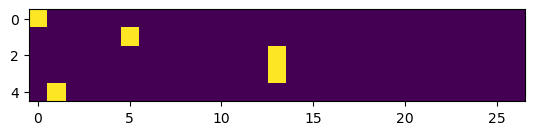

In [ ]:
plt.imshow(xenc)

In [ ]:
xenc.dtype

torch.float32

In [ ]:
W = torch.randn((27, 27))
xenc @ W  # (5, 27) @ (27, 27) -> (5, 27). Note that this is a standard linear layer without bias.

tensor([[-6.0264e-01,  7.5555e-02,  1.4870e+00, -7.3171e-01, -1.2623e-01,
         -1.4273e-01, -1.4415e+00,  1.8882e-01,  3.5093e-01,  1.5044e+00,
         -4.2113e-01,  1.8499e+00, -2.0196e+00, -1.8421e-01,  2.4277e-02,
          1.3939e+00, -2.4372e-01, -6.0917e-01,  2.7086e-01, -1.2480e+00,
         -1.5719e+00, -2.0827e-01,  7.9615e-02,  3.0861e-01, -3.6887e-01,
          4.7915e-01,  9.1488e-01],
        [ 3.0909e-01, -8.9362e-01,  6.6659e-02, -6.3792e-01, -2.7670e+00,
         -3.8036e+00, -1.2657e+00,  1.0259e+00,  7.0534e-01, -3.7011e-01,
          1.0627e-01, -1.0912e+00, -9.1892e-01,  4.7095e-01, -9.7588e-04,
          4.2337e-01, -7.5573e-01, -7.3067e-01,  1.2550e+00, -9.1546e-02,
         -2.1609e+00, -1.7497e+00, -1.5285e+00,  3.6947e-01,  1.1214e+00,
          8.9507e-02,  8.1418e-01],
        [-2.0873e+00, -9.7465e-01,  5.9874e-01,  1.0727e+00,  4.1052e-01,
          1.1549e+00,  1.1206e+00,  3.8411e-02, -6.1028e-01, -1.0921e+00,
          1.4303e+00,  6.4490e-01,  3.19

In [ ]:
# Weighted Sum and Softmax Function
logits = xenc @ W  # log-counts
counts = logits.exp()  # counts, equivalent to the N matrix (not really, just interpretation)
probs = counts / counts.sum(1, keepdim=True)
probs

tensor([[0.0137, 0.0270, 0.1109, 0.0121, 0.0221, 0.0217, 0.0059, 0.0303, 0.0356,
         0.1129, 0.0165, 0.1595, 0.0033, 0.0209, 0.0257, 0.1011, 0.0197, 0.0136,
         0.0329, 0.0072, 0.0052, 0.0204, 0.0272, 0.0341, 0.0173, 0.0405, 0.0626],
        [0.0470, 0.0141, 0.0369, 0.0182, 0.0022, 0.0008, 0.0097, 0.0963, 0.0699,
         0.0238, 0.0384, 0.0116, 0.0138, 0.0553, 0.0345, 0.0527, 0.0162, 0.0166,
         0.1211, 0.0315, 0.0040, 0.0060, 0.0075, 0.0500, 0.1060, 0.0378, 0.0779],
        [0.0031, 0.0093, 0.0450, 0.0723, 0.0373, 0.0785, 0.0758, 0.0257, 0.0134,
         0.0083, 0.1034, 0.0471, 0.0255, 0.0247, 0.0147, 0.0437, 0.0233, 0.0424,
         0.0417, 0.0425, 0.0110, 0.0178, 0.0269, 0.0442, 0.0268, 0.0859, 0.0098],
        [0.0031, 0.0093, 0.0450, 0.0723, 0.0373, 0.0785, 0.0758, 0.0257, 0.0134,
         0.0083, 0.1034, 0.0471, 0.0255, 0.0247, 0.0147, 0.0437, 0.0233, 0.0424,
         0.0417, 0.0425, 0.0110, 0.0178, 0.0269, 0.0442, 0.0268, 0.0859, 0.0098],
        [0.0731, 0.0239,

In [ ]:
# Network prediction for next characters for the first example
probs[0]

tensor([0.0137, 0.0270, 0.1109, 0.0121, 0.0221, 0.0217, 0.0059, 0.0303, 0.0356,
        0.1129, 0.0165, 0.1595, 0.0033, 0.0209, 0.0257, 0.1011, 0.0197, 0.0136,
        0.0329, 0.0072, 0.0052, 0.0204, 0.0272, 0.0341, 0.0173, 0.0405, 0.0626])

# SUMMARY ------------------------------>>>>>

In [ ]:
xs

tensor([ 0,  5, 13, 13,  1])

In [ ]:
ys

tensor([ 5, 13, 13,  1,  0])

In [ ]:
# Randomly initialize 27 neurons' weights. Each neuron recieves 27 inputs.
g = torch.Generator().manual_seed(2147483647 + 1)
W = torch.randn((27, 27), generator=g)

In [ ]:
# Forward Pass
xenc = F.one_hot(xs, num_classes=27).float()  # input to the network: one-hot encoded
logits = xenc @ W  # predict log-counts
counts = logits.exp()  # "counts", equivalent to N
probs = counts / counts.sum(1, keepdim=True)  # softmax probabilites

In [ ]:
probs.shape

torch.Size([5, 27])

In [ ]:
# Calculate loss as negative log likelihood (Same as cross-entropy loss)
nlls = torch.zeros(5)

In [ ]:
# Breakdown of examples + loss for just first word
nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram:
    x = xs[i].item() # input character index
    y = ys[i].item() # label character index
    print('--------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
    print('input to the neural net:', x)
    print('output probabilities from the neural net:', probs[i])
    print('label (actual next character):', y)
    p = probs[i, y]
    print('probability assigned by the net to the the correct character:', p.item())
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll

print('==========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0049, 0.0959, 0.0281, 0.0703, 0.0961, 0.0573, 0.0241, 0.0135, 0.0093,
        0.1416, 0.0225, 0.0217, 0.0513, 0.0106, 0.0097, 0.0291, 0.0229, 0.0273,
        0.0325, 0.0275, 0.0446, 0.0501, 0.0214, 0.0093, 0.0120, 0.0354, 0.0310])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.057345062494277954
log likelihood: -2.858668565750122
negative log likelihood: 2.858668565750122
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0426, 0.0113, 0.0266, 0.0507, 0.2370, 0.0580, 0.0421, 0.0094, 0.0136,
        0.0297, 0.0044, 0.0782, 0.1028, 0.0146, 0.0172, 0.0288, 0.0263, 0.0319,
        0.0248, 0.0210, 0.0063, 0.0057, 0.0309, 0.0269, 0.0298, 0.0089, 0.0205])
label (actual next character): 13
probability assigned by the net to the the correct character: 0

# OPTIMIZATION -------------------->>>>>

In [ ]:
xs

tensor([ 0,  5, 13, 13,  1])

In [ ]:
ys

tensor([ 5, 13, 13,  1,  0])

In [ ]:
# Randomly initialize 27 neurons' weights. Each neuron recieves 27 inputs.
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [ ]:
# Forward Pass
xenc = F.one_hot(xs, num_classes=27).float()  # input to the network: one-hot encoded
logits = xenc @ W  # predict log-counts
counts = logits.exp()  # "counts", equivalent to N
probs = counts / counts.sum(1, keepdim=True)  # softmax probabilites
loss = -probs[torch.arange(5), ys].log().mean()

In [ ]:
print(loss.item())

3.7693049907684326


In [ ]:
# Backward Pass
W.grad = None  # zero_grad
loss.backward()


In [ ]:
W.data += -0.1 * W.grad

# Full Network

In [ ]:
# create the dataset
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [ ]:
# gradient descent
for k in range(100):

    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
    loss = -probs[torch.arange(num), ys].log().mean()
    print(loss.item())

    # backward pass
    W.grad = None # set to zero the gradient
    loss.backward()

    # update
    W.data += -50 * W.grad

2.4623453617095947
2.462298631668091
2.462252140045166
2.4622061252593994
2.46216082572937
2.462116003036499
2.462071418762207
2.4620275497436523
2.461984157562256
2.4619410037994385
2.4618985652923584
2.4618563652038574
2.4618144035339355
2.46177339553833
2.4617323875427246
2.4616918563842773
2.4616518020629883
2.4616119861602783
2.4615728855133057
2.461534023284912
2.4614956378936768
2.4614572525024414
2.4614193439483643
2.4613821506500244
2.4613449573516846
2.461308240890503
2.4612717628479004
2.461236000061035
2.46120023727417
2.461164951324463
2.461129903793335
2.461095094680786
2.4610605239868164
2.461026668548584
2.4609932899475098
2.4609594345092773
2.4609262943267822
2.460893392562866
2.4608612060546875
2.4608287811279297
2.46079683303833
2.4607653617858887
2.4607341289520264
2.460702896118164
2.460671901702881
2.4606411457061768
2.460610866546631
2.460580587387085
2.4605510234832764
2.460521697998047
2.4604923725128174
2.460463047027588
2.4604344367980957
2.4604058265686035
2

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

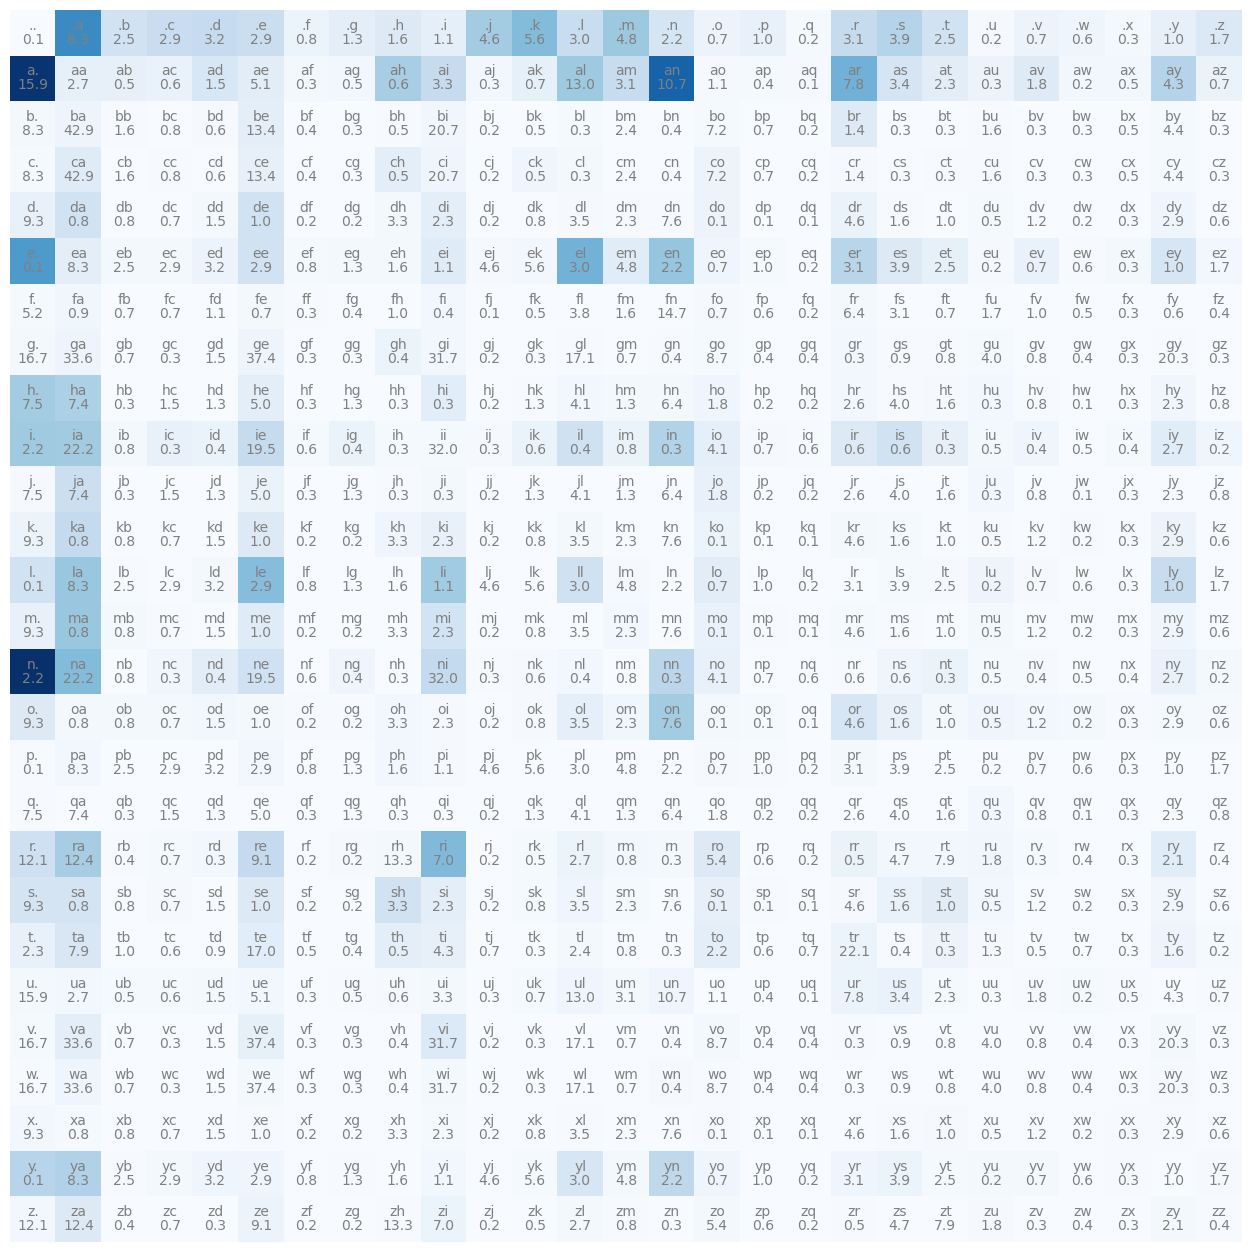

In [ ]:
rounded_counts = torch.round(counts, decimals=1)
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, f"{rounded_counts[i, j].item():.1f}", ha="center", va="top", color='gray')

plt.axis('off')

## Regularization
Here, we use L2 regularization.

In [ ]:
# create the dataset
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [ ]:
# gradient descent WITH L2
for k in range(100):

    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()  # ADD REGULARIZATION LOSS ***
    # loss = -probs[torch.arange(num), ys].log().mean()
    print(loss.item())

    # backward pass
    W.grad = None # set to zero the gradient
    loss.backward()

    # update
    W.data += -50 * W.grad

2.483029365539551
2.482990264892578
2.4829537868499756
2.482919216156006
2.48288631439209
2.4828548431396484
2.4828248023986816
2.4827957153320312
2.4827678203582764
2.482740640640259
2.4827141761779785
2.4826884269714355
2.482663869857788
2.482639789581299
2.482616424560547
2.482593536376953
2.4825711250305176
2.4825494289398193
2.4825282096862793
2.4825074672698975
2.482487201690674
2.4824676513671875
2.482447862625122
2.482429027557373
2.482409954071045
2.4823920726776123
2.4823741912841797
2.4823570251464844
2.482339859008789
2.482323169708252
2.482306480407715
2.482290506362915
2.4822745323181152
2.4822587966918945
2.482243299484253
2.4822282791137695
2.4822134971618652
2.482198715209961
2.482184410095215
2.482170343399048
2.482156276702881
2.482142686843872
2.4821293354034424
2.482116222381592
2.482103109359741
2.4820902347564697
2.4820775985717773
2.482065200805664
2.482052803039551
2.4820406436920166
2.4820287227630615
2.4820168018341064
2.4820053577423096
2.4819936752319336
2.

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

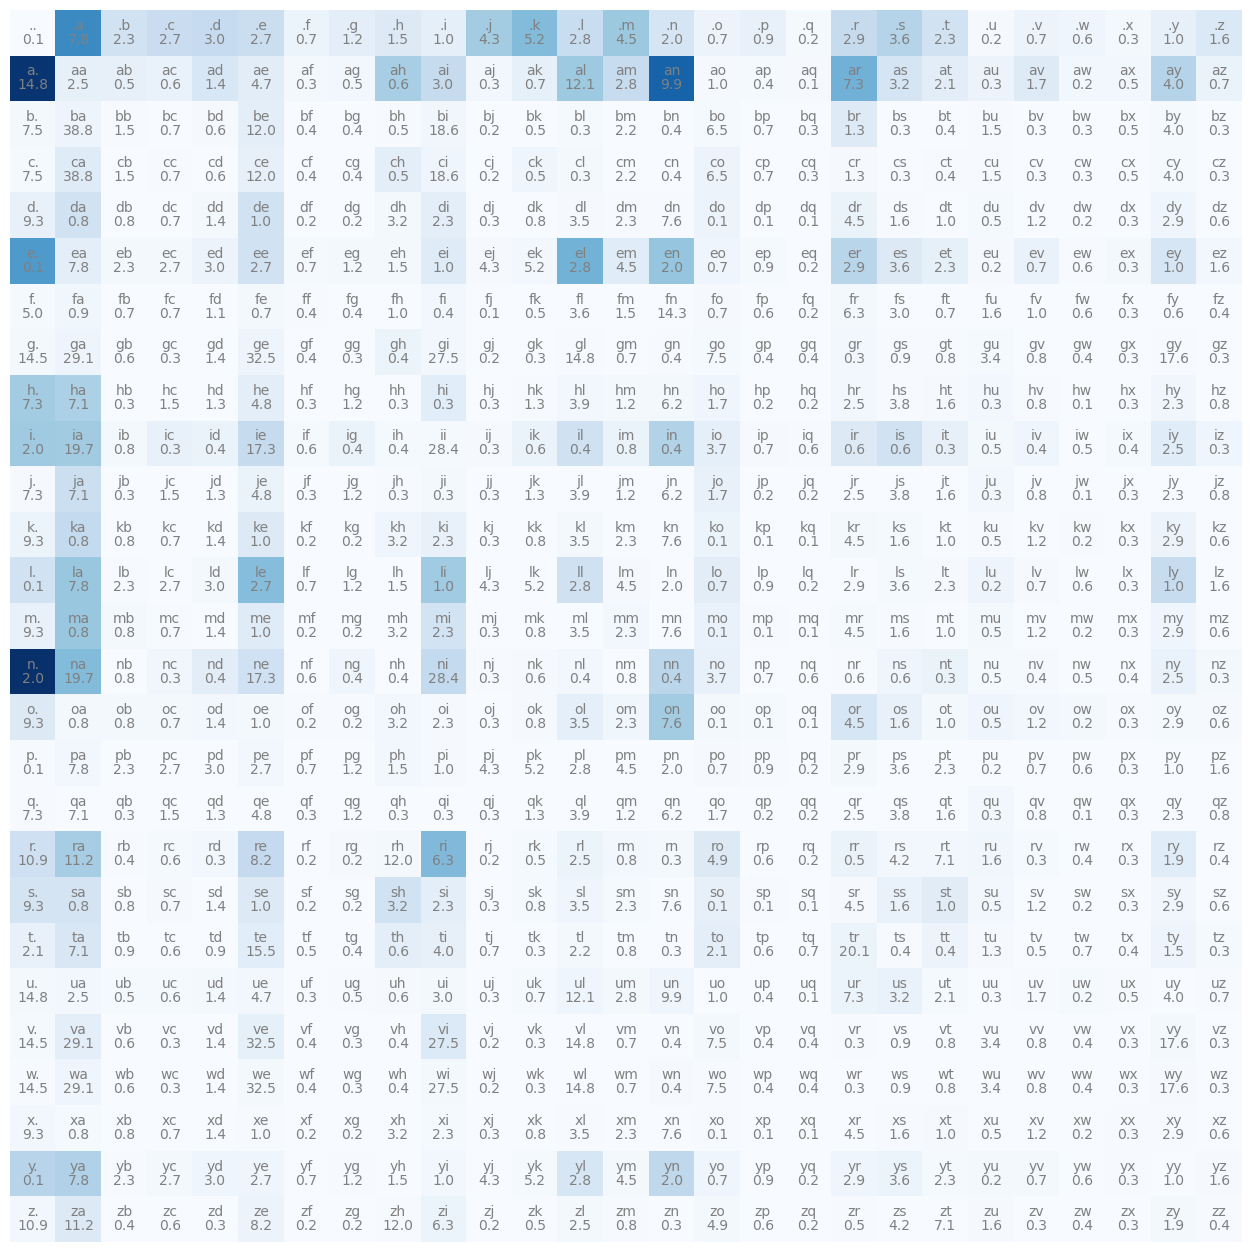

In [ ]:
rounded_counts = torch.round(counts, decimals=1)
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, f"{rounded_counts[i, j].item():.1f}", ha="center", va="top", color='gray')

plt.axis('off')

## Sampling

In [ ]:
# Finally, we can sample from the Neural Net
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        # BEFORE -------
        # p = P[ix]
        # --------------
        # AFTER --------
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float() # input to the network: one-hot encoding
        logits = xenc @ W # predict log-counts
        counts = logits.exp() # counts, equivalent to N
        probs = counts / counts.sum(1, keepdims=True) # probabilities for next character

        # --------------

        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.
